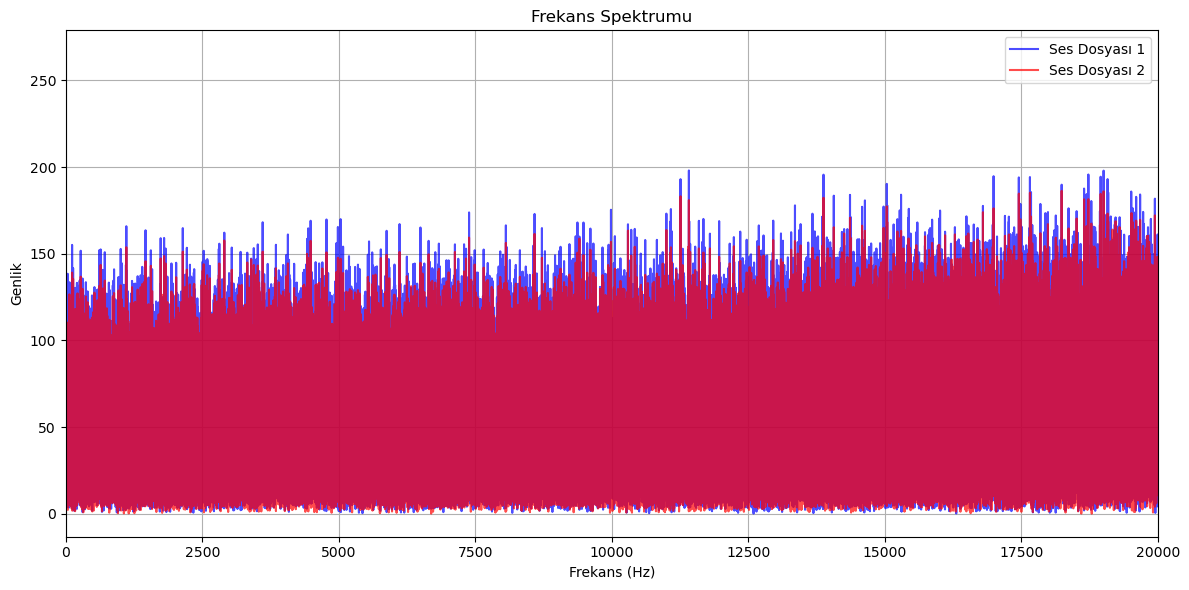

In [15]:
import matplotlib.pyplot as plt # Grafik çizimleri için kullanılan kütüphane
import numpy as np # Sayısal hesaplamaları
import librosa # Ses yükleme ve analizi
import librosa.display # Ses dalga formu görselleştirme

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/processed/teletronix_white_noise.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/processed/urei_white_noise.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükleme
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# FFT (Hızlı Fourier Dönüşümü) ile frekans spektrumunu hesaplama
def compute_fft(signal, sr):
    fft = np.fft.fft(signal) # Fourier dönüşümünü uygulama
    magnitude = np.abs(fft[:len(fft)//2]) # Sadece pozitif frekans bileşenlerini alma
    freqs = np.fft.fftfreq(len(fft), 1/sr)[:len(fft)//2] # Frekans eksenini oluşturma
    return freqs, magnitude

# Her iki ses için frekans spektrumunu hesaplama
freqs1, mag1 = compute_fft(wave_1, sr_1) # Birinci sesin spektrumu
freqs2, mag2 = compute_fft(wave_2, sr_2) # İkinci sesin spektrumu

# Grafik oluşturma
plt.figure(figsize=(12, 6)) # Grafik boyutunu belirleme

# Frekans spektrumlarının çizimi
plt.plot(freqs1, mag1, label="Ses Dosyası 1", color="blue", alpha=0.7) # Birinci sesin mavi olarak çizimi ve isimlendirme
plt.plot(freqs2, mag2, label="Ses Dosyası 2", color="red", alpha=0.7) # Birinci sesin mavi olarak çizimi ve isimlendirme

# Grafik başlığı ve etiketleri
plt.title("Frekans Spektrumu") # Başlık
plt.xlabel("Frekans (Hz)") # X ekseni etiketi
plt.ylabel("Genlik") # Y ekseni etiketi
plt.legend() # Açıklama kutusu
plt.grid(True) # Grafik ızgara çizgileri
plt.xlim(0, 20000) # Görüntülenen frekans aralığını sınırlama
plt.tight_layout() # Grafik içeriğini sıkılaştırma
plt.show() # Grafiği ekranda gösterme
